# Lattice ABP $\phi$-$v_0$ Phase Diagram (L40S)

This standalone notebook scans packing fraction and propulsion speed using the exact `cuda_fused` random-sequential lattice dynamics. It does **not** modify `mips_demo.ipynb`.

The primary phase-separation indicator is the lowest-wave-number density amplitude; a second, local observable counts occupied cells whose four cardinal neighbors are occupied. Their means, variances, covariance, and finite-size fluctuation ridges are saved together. No Gaussian/coarse-density image is used. Every state point is checkpointed separately so an interrupted scan can resume without repeating completed points.

> With the default `L=16`, `grid_size=32`, and `sigma=0.5`, this is a finite-size **lattice-model state map**. The final section explains the separate system-size and continuum-grid checks required before comparing quantitatively with a continuum ABP phase diagram.

## 0. One-time L40S environment setup

Install packages into the same Python environment as this Jupyter kernel:

```bash
python -m pip install -r data/lattice_abp_tc/requirements-l40s.txt
```

Install CUDA-enabled PyTorch separately using the [official PyTorch selector](https://pytorch.org/get-started/locally/). The fused backend additionally requires a full NVIDIA CUDA Toolkit containing `nvcc`, Ninja, and a compatible host C++ compiler. Restart the Jupyter kernel after changing PyTorch, CUDA, or compiler settings.

In [1]:
from pathlib import Path
import importlib.util
import os
import shutil
import subprocess
import sys


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "lattice_abp_tc" / "core.py").exists():
            return path
    raise RuntimeError("Could not find the CNEEP_v2 repository root.")


ROOT = find_repo_root("/home/ldh041203/projects/CNEEP_v2")
GPU_REQUIREMENTS = ROOT / "data" / "lattice_abp_tc" / "requirements-l40s.txt"

# These variables must be set before importing torch or the simulator package.
bootstrap_nvcc = shutil.which("nvcc.exe" if os.name == "nt" else "nvcc")
if bootstrap_nvcc and "CUDA_HOME" not in os.environ:
    os.environ["CUDA_HOME"] = str(Path(bootstrap_nvcc).resolve().parents[1])
os.environ.setdefault("TORCH_CUDA_ARCH_LIST", "8.9")
os.environ.setdefault("MAX_JOBS", str(min(8, os.cpu_count() or 1)))

required_modules = ("numpy", "matplotlib", "tqdm", "ninja", "setuptools")
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]

if missing_modules:
    print("Installing missing notebook packages:", ", ".join(missing_modules))
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-r",
        str(GPU_REQUIREMENTS),
    ])
else:
    print("Notebook pip dependencies are already installed.")

if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "PyTorch is missing. Install a CUDA-enabled torch wheel from "
        "https://pytorch.org/get-started/locally/ and restart the kernel."
    )

print("repo:", ROOT)
print("python:", sys.executable)

Notebook pip dependencies are already installed.
repo: /home/ldh041203/projects/CNEEP_v2
python: /home/ldh041203/.conda/envs/jupyter-gpu/bin/python


In [2]:
import gc
import json
import math
import platform
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.cpp_extension import CUDA_HOME, is_ninja_available


if not torch.cuda.is_available():
    raise RuntimeError(
        f"This kernel cannot see CUDA (torch={torch.__version__}, "
        f"torch.version.cuda={torch.version.cuda}). Select a CUDA-enabled kernel."
    )

DEVICE = torch.device("cuda:0")
gpu = torch.cuda.get_device_properties(DEVICE)
capability = torch.cuda.get_device_capability(DEVICE)
if capability != (8, 9):
    warnings.warn(
        f"Expected an L40S (compute capability 8.9), found {gpu.name} "
        f"with capability {capability[0]}.{capability[1]}."
    )

nvcc_name = "nvcc.exe" if os.name == "nt" else "nvcc"
nvcc = None
if CUDA_HOME is not None:
    candidate = Path(CUDA_HOME) / "bin" / nvcc_name
    if candidate.is_file():
        nvcc = str(candidate)
if nvcc is None:
    nvcc = shutil.which(nvcc_name)

host_compiler = (
    shutil.which("cl.exe")
    if os.name == "nt"
    else (shutil.which("c++") or shutil.which("g++") or shutil.which("clang++"))
)

toolchain_errors = []
if torch.version.cuda is None:
    toolchain_errors.append("Installed PyTorch is a CPU-only build.")
if CUDA_HOME is None:
    toolchain_errors.append("CUDA_HOME was not detected by torch.utils.cpp_extension.")
elif not (Path(CUDA_HOME) / "bin" / nvcc_name).is_file():
    toolchain_errors.append(f"CUDA_HOME={CUDA_HOME} does not contain bin/{nvcc_name}.")
if nvcc is None:
    toolchain_errors.append("nvcc was not found; install the full CUDA Toolkit.")
if host_compiler is None:
    toolchain_errors.append("No compatible host C++ compiler was found on PATH.")
if not is_ninja_available():
    toolchain_errors.append("Ninja is unavailable in this kernel environment.")
if toolchain_errors:
    raise RuntimeError("L40S fused-backend prerequisites failed:\n- " + "\n- ".join(toolchain_errors))

nvcc_output = subprocess.run(
    [nvcc, "--version"], capture_output=True, text=True, check=True
).stdout.strip()
nvcc_version = nvcc_output.splitlines()[-1]
version_match = re.search(r"release\s+(\d+)\.(\d+)", nvcc_output)
if version_match and torch.version.cuda:
    nvcc_major, nvcc_minor = map(int, version_match.groups())
    torch_major, torch_minor = map(int, torch.version.cuda.split(".")[:2])
    if nvcc_major != torch_major:
        raise RuntimeError(
            f"CUDA major mismatch: torch wheel={torch.version.cuda}, "
            f"nvcc={nvcc_major}.{nvcc_minor}."
        )
    if nvcc_minor != torch_minor:
        warnings.warn(
            f"CUDA minor versions differ: torch wheel={torch.version.cuda}, "
            f"nvcc={nvcc_major}.{nvcc_minor}."
        )

print(f"GPU: {gpu.name} ({gpu.total_memory / 2**30:.1f} GiB, sm_{capability[0]}{capability[1]})")
print(f"PyTorch: {torch.__version__}, wheel CUDA: {torch.version.cuda}")
print(f"CUDA_HOME: {CUDA_HOME}")
print(f"nvcc: {nvcc_version}")
print(f"host compiler: {host_compiler}")
print(f"platform: {platform.platform()}")

GPU: NVIDIA L40S (44.5 GiB, sm_89)
PyTorch: 2.6.0+cu124, wheel CUDA: 12.4
CUDA_HOME: /tools/cuda/cuda12.4
nvcc: Build cuda_12.4.r12.4/compiler.33961263_0
host compiler: /usr/bin/c++
platform: Linux-5.15.0-94-generic-x86_64-with-glibc2.27


In [3]:
# Compile/load once before starting a long parameter scan.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from data.lattice_abp_tc._cuda_backend import cuda_backend_buildable, load_cuda_backend

if not cuda_backend_buildable():
    raise RuntimeError("The fused CUDA backend is not buildable; review the environment cell above.")

cuda_extension = load_cuda_backend(verbose=True)
print("fused CUDA extension ready:", cuda_extension.__name__)

from data.lattice_abp_tc import ThermodynamicLatticeABP, ThermodynamicLatticeABPParams

Using /home/ldh041203/.cache/torch_extensions/py312_cu124 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/ldh041203/.cache/torch_extensions/py312_cu124/lattice_abp_cuda_b8770453e713/build.ninja...
Building extension module lattice_abp_cuda_b8770453e713...
Using envvar MAX_JOBS (8) as the number of workers...


ninja: no work to do.
fused CUDA extension ready: lattice_abp_cuda_b8770453e713


Loading extension module lattice_abp_cuda_b8770453e713...


In [4]:
# Tiny exact-backend smoke test, including parallel replicas.
smoke_params = ThermodynamicLatticeABPParams(
    N=8,
    L=6.0,
    grid_size=24,
    sigma=1.0,
    epsilon=1.0,
    v0=2.0,
    Dr=1.0,
    Dt=0.5,
    dt=1.0e-4,
    prefactor="cv",
    strict_probabilities=True,
    shuffle_particles=True,
    seed=123,
    device=str(DEVICE),
    backend="cuda_fused",
)

smoke_sim = ThermodynamicLatticeABP(smoke_params)
smoke = smoke_sim.simulate(
    B=2,
    n_steps=2,
    save_interval=1,
    show_progress=False,
    save_diagnostics=False,
    save_occupancy=True,
    save_exact_medium_ep=True,
)

rebuilt = smoke_sim.occupancy_from_sites(smoke["sites"][-1].to(DEVICE)).cpu()
assert torch.equal(rebuilt, smoke["occupancy"][-1])
assert bool(torch.isfinite(smoke["exact_medium_ep"]).all())
assert smoke_sim.backend == "cuda_fused"
print("2-step fused CUDA smoke test passed.")

del smoke, smoke_sim
torch.cuda.empty_cache()

2-step fused CUDA smoke test passed.


## 1. Phase indicator

Only `phi` (through integer `N`) and `v0` change within one scan. The lower horizontal axis is `v0`; the corresponding rotational Péclet number is

$$Pe_r=\frac{v_0}{D_r\sigma}.$$

The lowest density Fourier modes are translation invariant, so a cluster crossing a periodic boundary is still detected correctly. Define

$$m_1^2=\frac{|\rho_{(1,0)}|^2+|\rho_{(0,1)}|^2}{2N^2}.$$

For a homogeneous phase, `m1_sq` decreases approximately as `1/N`; for macrophase separation it remains order one as the system grows. `m_low` also includes diagonal modes so a diagonal band is not missed; it is stored as a morphology diagnostic, while the critical fluctuation calculation keeps the standard first-shell `m1` definition.

A complementary local observable counts occupied center cells whose four hopping neighbors are all occupied. Its particle fraction is `bulk4_fraction`. Because a homogeneous dense lattice already produces such crosses by chance, the notebook subtracts the exact random-without-replacement baseline

$$p_{4,0}=\prod_{j=0}^{3}\frac{N-1-j}{G^2-1-j},\qquad q_4=\frac{f_{bulk4}-p_{4,0}}{1-p_{4,0}}.$$

`m1` measures global macrophase separation, while `q4` measures excess compact-cluster interior. The notebook retains both raw variances and the fixed-$N$ susceptibility convention

$$\chi_1=N\,\mathrm{Var}(m_1),\qquad \chi_4=N\,\mathrm{Var}(f_{bulk4}).$$

It also stores the minimum-wavevector structure factor $S(k_{min})=N\langle m_1^2\rangle$, which is not the same quantity as $\chi_1$. For a joint fluctuation diagnostic, set $x=(m_1,q_4)$ and use the fixed, scan-wide scale $D=\mathrm{diag}(1,1)$ (both observables have a natural unit upper range):

$$C=N\,\mathrm{Cov}(D^{-1}x),\qquad \chi_{joint}=\lambda_{max}(C).$$

The three susceptibility ridges are finite-size critical **candidates**, not a thermodynamic critical-point proof. A checkerboard order parameter is recorded separately to distinguish square-lattice ordering from long-wavelength phase separation.

In [5]:
def n_from_packing_fraction(phi, box_size, sigma):
    return int(round(phi * 4.0 * box_size * box_size / (math.pi * sigma * sigma)))


def atomic_savez(path, **arrays):
    """Write one NPZ checkpoint atomically within its destination directory."""
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp.npz")
    np.savez_compressed(temporary, **arrays)
    os.replace(temporary, path)


def atomic_write_json(path, payload):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    os.replace(temporary, path)


@torch.no_grad()
def phase_modes_from_sites(sites, grid_size):
    """Return time/replica-resolved low-k and checkerboard observables.

    Parameters
    ----------
    sites : CPU tensor [T, B, N, 2]
    grid_size : int
    """
    sites = sites.to(torch.long).cpu()
    T, B, N, _ = sites.shape
    G = int(grid_size)

    flat = sites[..., 0] * G + sites[..., 1]
    occupancy = torch.zeros(T, B, G * G, dtype=torch.float32)
    occupancy.scatter_add_(
        -1,
        flat,
        torch.ones_like(flat, dtype=torch.float32),
    )
    occupancy = occupancy.view(T, B, G, G)

    spectrum = torch.fft.fft2(occupancy)
    m1_sq = (
        spectrum[..., 1, 0].abs().square()
        + spectrum[..., 0, 1].abs().square()
    ) / (2.0 * N * N)

    m_diag_sq = (
        spectrum[..., 1, 1].abs().square()
        + spectrum[..., 1, -1].abs().square()
    ) / (2.0 * N * N)

    low_modes = torch.stack(
        (
            spectrum[..., 1, 0].abs(),
            spectrum[..., 0, 1].abs(),
            spectrum[..., 1, 1].abs(),
            spectrum[..., 1, -1].abs(),
        ),
        dim=-1,
    )
    m_low = low_modes.amax(dim=-1) / float(N)

    occupied = occupancy > 0.5
    occupied_i = occupied.to(torch.int16)
    neighbor_count = (
        torch.roll(occupied_i, shifts=1, dims=-2)
        + torch.roll(occupied_i, shifts=-1, dims=-2)
        + torch.roll(occupied_i, shifts=1, dims=-1)
        + torch.roll(occupied_i, shifts=-1, dims=-1)
    )
    bulk4_mask = occupied & (neighbor_count == 4)
    bulk4_count = bulk4_mask.sum(dim=(-2, -1))
    bulk4_fraction = bulk4_count.to(torch.float32) / float(N)

    if N < 5:
        bulk4_random_baseline = 0.0
    else:
        bulk4_random_baseline = 1.0
        for j in range(4):
            bulk4_random_baseline *= (N - 1 - j) / (G * G - 1 - j)
    bulk4_excess = (
        bulk4_fraction - bulk4_random_baseline
    ) / max(1.0 - bulk4_random_baseline, 1.0e-12)

    parity = 1 - 2 * (sites[..., 0] + sites[..., 1]).remainder(2)
    m_checker = parity.sum(dim=-1).abs().to(torch.float32) / float(N)

    return {
        "m1_sq": m1_sq.numpy(),
        "m_diag_sq": m_diag_sq.numpy(),
        "m_low": m_low.numpy(),
        "bulk4_count": bulk4_count.numpy(),
        "bulk4_fraction": bulk4_fraction.numpy(),
        "bulk4_random_baseline": float(bulk4_random_baseline),
        "bulk4_excess": bulk4_excess.numpy(),
        "m_checker": m_checker.numpy(),
        "initial_occupancy": occupancy[0, 0].to(torch.uint8).numpy(),
        "final_occupancy": occupancy[-1, 0].to(torch.uint8).numpy(),
    }


# CPU sanity check: random fixed-N occupancy has <q4> ~= 0, while a band is large.
analysis_test_sites = torch.tensor(
    [[[[x, y] for x in range(4) for y in range(8)]]],
    dtype=torch.long,
)
analysis_test = phase_modes_from_sites(analysis_test_sites, grid_size=8)
analysis_generator = torch.Generator().manual_seed(20260731)
analysis_random_flat = torch.stack([
    torch.randperm(64, generator=analysis_generator)[:32] for _ in range(128)
])
analysis_random_sites = torch.stack(
    (analysis_random_flat // 8, analysis_random_flat % 8), dim=-1
).unsqueeze(0)
analysis_random = phase_modes_from_sites(analysis_random_sites, grid_size=8)
assert analysis_test["m_low"].shape == (1, 1)
assert analysis_test["m_diag_sq"].shape == (1, 1)
assert analysis_test["bulk4_excess"].shape == (1, 1)
assert abs(float(analysis_random["bulk4_excess"].mean())) < 0.05
assert float(analysis_test["bulk4_excess"][0, 0]) > float(analysis_random["bulk4_excess"].mean())
assert float(analysis_test["m1_sq"][0, 0]) > float(analysis_random["m1_sq"].mean())
assert 0.0 <= float(analysis_test["m_checker"][0, 0]) <= 1.0
print("phase-observable analysis check passed")

phase-observable analysis check passed


## 2. Scan configuration

`pilot` locates the crossover region. It is not a converged binodal. After inspecting the pilot heatmap, reduce the `phi` and `Pe` spacing around the crossover, set `RUN_MODE="production"`, and choose a new `OUTPUT_TAG`.

The production defaults use about 45 rotational relaxation times for burn-in and another 45 for measurement. Near a nucleation boundary or during slow coarsening, longer runs may still be required. If strict probability validation fails at any point, do not clip or renormalize probabilities: choose a smaller `dt` for the entire comparable scan and use a new `OUTPUT_TAG`.

In [6]:
# ------------------------ user configuration ------------------------
RUN_MODE = "pilot"  # "pilot" or "production"
OUTPUT_TAG = "coarse_v1"  # change this whenever the grid/configuration changes
SEED_GROUP = 0  # increment for an independent production repeat

L = 16.0
GRID_SIZE = 32
SIGMA = 0.5
EPSILON = 1.0
MOBILITY = 1.0
DR = 1.5
DT = 1.0
TIME_STEP = 1.0e-4
DTYPE = "float32"
PROBABILITY_TOLERANCE = 1.0e-6
JOINT_SCALES = np.array([1.0, 1.0], dtype=float)  # fixed for the entire scan: (m1, q4)

# Coarse pilot. Example refinement: dphi=0.025 and dPe=5 near the boundary.
PHI_TARGETS = np.array([0.10, 0.20, 0.30, 0.40, 0.50, 0.60], dtype=float)
PE_TARGETS = np.array([0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0], dtype=float)
V_VALUES = PE_TARGETS * DR * SIGMA
RIDGE_AGREEMENT_PE = 15.0  # use 5.0 when refining with dPe=5

if RUN_MODE == "pilot":
    B = 8
    BURN_IN = 100_000
    N_STEPS = 100_000
elif RUN_MODE == "production":
    B = 16
    BURN_IN = 300_000
    N_STEPS = 300_000
else:
    raise ValueError("RUN_MODE must be 'pilot' or 'production'.")

SAVE_INTERVAL = 2_000
if N_STEPS % SAVE_INTERVAL != 0:
    raise ValueError("N_STEPS must be divisible by SAVE_INTERVAL so the final frame is saved.")
if B < 1 or N_STEPS // SAVE_INTERVAL < 4:
    raise ValueError("Use B >= 1 and save at least four production frames.")

if np.any(PHI_TARGETS <= 0):
    raise ValueError("All packing fractions must be positive.")
if np.any(V_VALUES < 0):
    raise ValueError("All propulsion speeds must be nonnegative.")
if not isinstance(SEED_GROUP, int) or SEED_GROUP < 0:
    raise ValueError("SEED_GROUP must be a nonnegative integer.")
if DR <= 0 or DT <= 0 or SIGMA <= 0 or TIME_STEP <= 0:
    raise ValueError("DR, DT, SIGMA, and TIME_STEP must all be positive.")
if JOINT_SCALES.shape != (2,) or np.any(JOINT_SCALES <= 0):
    raise ValueError("JOINT_SCALES must contain two positive, fixed values.")
if RIDGE_AGREEMENT_PE < 0:
    raise ValueError("RIDGE_AGREEMENT_PE must be nonnegative.")
if GRID_SIZE % 2 != 0:
    raise ValueError("GRID_SIZE must be even for the checkerboard diagnostic.")

max_particles = max(
    n_from_packing_fraction(float(phi), L, SIGMA)
    for phi in PHI_TARGETS
)
if max_particles > GRID_SIZE * GRID_SIZE:
    raise ValueError(
        f"The scan needs up to N={max_particles}, but only {GRID_SIZE**2} sites exist."
    )

OUTDIR = ROOT / "output" / (
    f"lattice_phase_{RUN_MODE}_{OUTPUT_TAG}_seed{SEED_GROUP:03d}"
)
OUTDIR.mkdir(parents=True, exist_ok=True)

scan_config = {
    "analysis_version": 5,
    "run_mode": RUN_MODE,
    "seed_group": SEED_GROUP,
    "L": L,
    "grid_size": GRID_SIZE,
    "sigma": SIGMA,
    "epsilon": EPSILON,
    "mobility": MOBILITY,
    "Dr": DR,
    "Dt": DT,
    "dt": TIME_STEP,
    "dtype": DTYPE,
    "probability_tolerance": PROBABILITY_TOLERANCE,
    "phi_targets": PHI_TARGETS.tolist(),
    "Pe_targets": PE_TARGETS.tolist(),
    "v_values": V_VALUES.tolist(),
    "B": B,
    "burn_in": BURN_IN,
    "n_steps": N_STEPS,
    "save_interval": SAVE_INTERVAL,
    "prefactor": "cv",
    "strict_probabilities": True,
    "shuffle_particles": True,
    "backend": "cuda_fused",
}

config_path = OUTDIR / "scan_config.json"
if config_path.exists():
    previous_config = json.loads(config_path.read_text(encoding="utf-8"))
    if previous_config != scan_config:
        raise RuntimeError(
            f"{config_path} belongs to a different configuration. "
            "Change OUTPUT_TAG instead of mixing checkpoints."
        )
else:
    atomic_write_json(config_path, scan_config)

# These settings only post-process saved point traces, so they may be changed
# without rerunning the GPU dynamics.
analysis_config = {
    "analysis_version": scan_config["analysis_version"],
    "joint_scales": JOINT_SCALES.tolist(),
    "ridge_agreement_Pe": RIDGE_AGREEMENT_PE,
}
atomic_write_json(OUTDIR / "analysis_config.json", analysis_config)

tau_r_steps = 1.0 / (DR * TIME_STEP)
print(f"state points: {len(PHI_TARGETS)} x {len(V_VALUES)} = {len(PHI_TARGETS)*len(V_VALUES)}")
print(f"v0 values: {V_VALUES}")
print(f"Pe_r values: {PE_TARGETS}")
print(f"burn-in: {BURN_IN/tau_r_steps:.1f} tau_r")
print(f"production: {N_STEPS/tau_r_steps:.1f} tau_r")
print(f"replicas per state point: B={B}")
print(f"output: {OUTDIR}")

state points: 6 x 7 = 42
v0 values: [ 0.   11.25 22.5  33.75 45.   56.25 67.5 ]
Pe_r values: [ 0. 15. 30. 45. 60. 75. 90.]
burn-in: 15.0 tau_r
production: 15.0 tau_r
replicas per state point: B=8
output: /home/ldh041203/projects/CNEEP_v2/output/lattice_phase_pilot_coarse_v1_seed000


## 3. Run or resume the scan

Different `(phi, v0)` points require different simulator instances. `B` is used only for parallel replicas of the **same** state point. Replica states and random draws differ, but the fused kernel shares each sweep's particle permutation across `B`; for final error bars, increment `SEED_GROUP`, repeat production, and compare independent group means. Each seed group gets its own output directory. The notebook stores sparse trajectory frames and computes observables on CPU; it does not store coarse-density fields or EP maps.

Turning off unused output does not alter transition probabilities or particle updates. `strict_probabilities=True`, the WCA cutoff, random-sequential sweep, and `dt` remain unchanged.

In [7]:
shape = (len(PHI_TARGETS), len(V_VALUES))
m1_mean = np.full(shape, np.nan)
m1_power = np.full(shape, np.nan)
m1_sem = np.full(shape, np.nan)
m1_power_sem = np.full(shape, np.nan)
structure_factor_kmin = np.full(shape, np.nan)
m_low_mean = np.full(shape, np.nan)
bulk4_fraction_mean = np.full(shape, np.nan)
bulk4_excess_mean = np.full(shape, np.nan)
bulk4_excess_sem = np.full(shape, np.nan)
m1_variance = np.full(shape, np.nan)
bulk4_fraction_variance = np.full(shape, np.nan)
bulk4_excess_variance = np.full(shape, np.nan)
cross_covariance_m1_bulk4_excess = np.full(shape, np.nan)
susceptibility_m1 = np.full(shape, np.nan)
susceptibility_bulk4 = np.full(shape, np.nan)
susceptibility_bulk4_excess = np.full(shape, np.nan)
susceptibility_joint = np.full(shape, np.nan)
m1_bulk4_correlation = np.full(shape, np.nan)
binder_m1 = np.full(shape, np.nan)
diagonal_power = np.full(shape, np.nan)
checkerboard = np.full(shape, np.nan)
m1_stationarity_drift = np.full(shape, np.nan)
bulk4_stationarity_drift = np.full(shape, np.nan)
phi_actual = np.full(len(PHI_TARGETS), np.nan)
particle_counts = np.array([
    n_from_packing_fraction(float(phi), L, SIGMA) for phi in PHI_TARGETS
], dtype=int)


def save_phase_summary(path, **extra):
    payload = {
        "analysis_version": scan_config["analysis_version"],
        "seed_group": SEED_GROUP,
        "phi_target": PHI_TARGETS,
        "phi_actual": phi_actual,
        "particle_count": particle_counts,
        "v0": V_VALUES,
        "Pe_r": PE_TARGETS,
        "joint_scales": JOINT_SCALES,
        "m1_mean": m1_mean,
        "m1_power": m1_power,
        "m1_sem": m1_sem,
        "m1_power_sem": m1_power_sem,
        "structure_factor_kmin": structure_factor_kmin,
        "m_low_mean": m_low_mean,
        "bulk4_fraction_mean": bulk4_fraction_mean,
        "bulk4_excess_mean": bulk4_excess_mean,
        "bulk4_excess_sem": bulk4_excess_sem,
        "m1_variance": m1_variance,
        "bulk4_fraction_variance": bulk4_fraction_variance,
        "bulk4_excess_variance": bulk4_excess_variance,
        "cross_covariance_m1_bulk4_excess": cross_covariance_m1_bulk4_excess,
        "susceptibility_m1": susceptibility_m1,
        "susceptibility_bulk4": susceptibility_bulk4,
        "susceptibility_bulk4_excess": susceptibility_bulk4_excess,
        "susceptibility_joint": susceptibility_joint,
        "m1_bulk4_correlation": m1_bulk4_correlation,
        "binder_m1_diagnostic": binder_m1,
        "diagonal_power": diagonal_power,
        "checkerboard": checkerboard,
        "m1_stationarity_drift": m1_stationarity_drift,
        "bulk4_stationarity_drift": bulk4_stationarity_drift,
    }
    payload.update(extra)
    atomic_savez(path, **payload)

scan_started = time.perf_counter()
accumulated_simulation_elapsed = 0.0
state_points_run_this_cell = 0
state_points_loaded = 0

for ip, phi_target in enumerate(PHI_TARGETS):
    particle_count = n_from_packing_fraction(float(phi_target), L, SIGMA)

    for iv, v0 in enumerate(V_VALUES):
        point_file = OUTDIR / f"point_phi{ip:03d}_v{iv:03d}.npz"
        point_seed = 10_000 + 1_000_000 * SEED_GROUP + 10_000 * ip + iv
        point_was_run = False

        if not point_file.exists():
            params = ThermodynamicLatticeABPParams(
                N=particle_count,
                L=L,
                grid_size=GRID_SIZE,
                sigma=SIGMA,
                epsilon=EPSILON,
                mobility=MOBILITY,
                v0=float(v0),
                Dr=DR,
                Dt=DT,
                dt=TIME_STEP,
                prefactor="cv",
                strict_probabilities=True,
                probability_tolerance=PROBABILITY_TOLERANCE,
                shuffle_particles=True,
                seed=point_seed,
                device=str(DEVICE),
                dtype=DTYPE,
                backend="cuda_fused",
            )
            simulator = ThermodynamicLatticeABP(params)
            assert simulator.device.type == "cuda"
            assert simulator.backend == "cuda_fused"

            torch.cuda.synchronize(DEVICE)
            point_started = time.perf_counter()
            result = simulator.simulate(
                B=B,
                burn_in=BURN_IN,
                n_steps=N_STEPS,
                save_interval=SAVE_INTERVAL,
                show_progress=False,
                save_diagnostics=False,
                save_occupancy=False,
                save_exact_medium_ep=False,
                save_ep_maps=False,
            )
            torch.cuda.synchronize(DEVICE)
            elapsed = time.perf_counter() - point_started

            observables = phase_modes_from_sites(result["sites"], GRID_SIZE)
            atomic_savez(
                point_file,
                analysis_version=scan_config["analysis_version"],
                seed=point_seed,
                target_phi=float(phi_target),
                actual_phi=float(params.phi),
                N=particle_count,
                site_density=float(particle_count / (GRID_SIZE * GRID_SIZE)),
                v0=float(v0),
                Pe_r=float(params.Pe),
                Pe_t=float(v0 * SIGMA / DT),
                hop_affinity=float(v0 * params.dl / DT),
                persistence_over_L=float(v0 / (DR * L)) if DR > 0 else np.inf,
                B=B,
                burn_in=BURN_IN,
                n_steps=N_STEPS,
                save_interval=SAVE_INTERVAL,
                elapsed_seconds=elapsed,
                times=result["times"].numpy(),
                m1_sq=observables["m1_sq"].astype(np.float32),
                m_diag_sq=observables["m_diag_sq"].astype(np.float32),
                m_low=observables["m_low"].astype(np.float32),
                bulk4_count=observables["bulk4_count"],
                bulk4_fraction=observables["bulk4_fraction"].astype(np.float32),
                bulk4_random_baseline=observables["bulk4_random_baseline"],
                bulk4_excess=observables["bulk4_excess"].astype(np.float32),
                m_checker=observables["m_checker"].astype(np.float32),
                initial_occupancy=observables["initial_occupancy"],
                final_occupancy=observables["final_occupancy"],
            )
            point_was_run = True

            del result, observables, simulator
            gc.collect()
            torch.cuda.empty_cache()

        with np.load(point_file) as point:
            if int(point["analysis_version"].item()) != scan_config["analysis_version"]:
                raise RuntimeError(f"Stale analysis version in {point_file}")
            if int(point["seed"].item()) != point_seed:
                raise RuntimeError(f"Stale seed in {point_file}")
            if int(point["N"].item()) != particle_count:
                raise RuntimeError(f"Stale particle count in {point_file}")
            if int(point["B"].item()) != B:
                raise RuntimeError(f"Stale replica count in {point_file}")
            if int(point["n_steps"].item()) != N_STEPS:
                raise RuntimeError(f"Stale trajectory length in {point_file}")
            if not np.isclose(float(point["v0"].item()), float(v0)):
                raise RuntimeError(f"Stale propulsion speed in {point_file}")
            expected_shape = (N_STEPS // SAVE_INTERVAL + 1, B)
            if point["m1_sq"].shape != expected_shape:
                raise RuntimeError(
                    f"Stale observable shape in {point_file}: "
                    f"{point['m1_sq'].shape} != {expected_shape}"
                )
            for observable_name in (
                "m_diag_sq", "m_low", "bulk4_count", "bulk4_fraction",
                "bulk4_excess", "m_checker",
            ):
                if point[observable_name].shape != expected_shape:
                    raise RuntimeError(
                        f"Stale {observable_name} shape in {point_file}: "
                        f"{point[observable_name].shape} != {expected_shape}"
                    )

            # Drop the first post-burn-in production frame.
            power_trace = point["m1_sq"][1:]
            amplitude_trace = np.sqrt(np.maximum(power_trace, 0.0))
            bulk4_fraction_trace = point["bulk4_fraction"][1:]
            bulk4_trace = point["bulk4_excess"][1:]
            per_replica_m1 = amplitude_trace.mean(axis=0)
            per_replica_power = power_trace.mean(axis=0)
            per_replica_bulk4_excess = bulk4_trace.mean(axis=0)

            m1_mean[ip, iv] = per_replica_m1.mean()
            m1_power[ip, iv] = per_replica_power.mean()
            m1_sem[ip, iv] = (
                per_replica_m1.std(ddof=1) / math.sqrt(B)
                if B > 1 else np.nan
            )
            m1_power_sem[ip, iv] = (
                per_replica_power.std(ddof=1) / math.sqrt(B)
                if B > 1 else np.nan
            )
            structure_factor_kmin[ip, iv] = particle_count * m1_power[ip, iv]
            m_low_mean[ip, iv] = point["m_low"][1:].mean()
            bulk4_fraction_mean[ip, iv] = bulk4_fraction_trace.mean()
            bulk4_excess_mean[ip, iv] = per_replica_bulk4_excess.mean()
            bulk4_excess_sem[ip, iv] = (
                per_replica_bulk4_excess.std(ddof=1) / math.sqrt(B)
                if B > 1 else np.nan
            )
            diagonal_power[ip, iv] = point["m_diag_sq"][1:].mean()

            flat_m1 = amplitude_trace.reshape(-1).astype(np.float64)
            flat_bulk4_fraction = bulk4_fraction_trace.reshape(-1).astype(np.float64)
            flat_bulk4 = bulk4_trace.reshape(-1).astype(np.float64)
            covariance_matrix = np.cov(
                np.stack((flat_m1, flat_bulk4), axis=0),
                bias=True,
            )
            m1_variance[ip, iv] = covariance_matrix[0, 0]
            bulk4_fraction_variance[ip, iv] = np.var(flat_bulk4_fraction, ddof=0)
            bulk4_excess_variance[ip, iv] = covariance_matrix[1, 1]
            cross_covariance_m1_bulk4_excess[ip, iv] = covariance_matrix[0, 1]
            susceptibility_m1[ip, iv] = particle_count * covariance_matrix[0, 0]
            susceptibility_bulk4[ip, iv] = (
                particle_count * bulk4_fraction_variance[ip, iv]
            )
            susceptibility_bulk4_excess[ip, iv] = (
                particle_count * covariance_matrix[1, 1]
            )
            scaled_covariance = covariance_matrix / np.outer(
                JOINT_SCALES, JOINT_SCALES
            )
            susceptibility_joint[ip, iv] = particle_count * np.linalg.eigvalsh(
                scaled_covariance
            )[-1]
            denominator = math.sqrt(
                max(covariance_matrix[0, 0] * covariance_matrix[1, 1], 0.0)
            )
            m1_bulk4_correlation[ip, iv] = (
                covariance_matrix[0, 1] / denominator
                if denominator > 0 else np.nan
            )
            second_moment = np.mean(flat_m1**2)
            fourth_moment = np.mean(flat_m1**4)
            binder_m1[ip, iv] = 1.0 - fourth_moment / max(
                3.0 * second_moment**2, 1.0e-30
            )
            checkerboard[ip, iv] = point["m_checker"][1:].mean()

            half = max(1, len(amplitude_trace) // 2)
            m1_stationarity_drift[ip, iv] = abs(
                amplitude_trace[:half].mean() - amplitude_trace[half:].mean()
            )
            bulk4_stationarity_drift[ip, iv] = abs(
                bulk4_trace[:half].mean() - bulk4_trace[half:].mean()
            )
            phi_actual[ip] = float(point["actual_phi"].item())
            elapsed = float(point["elapsed_seconds"].item())

        status = "ran" if point_was_run else "loaded"
        accumulated_simulation_elapsed += elapsed
        state_points_run_this_cell += int(point_was_run)
        state_points_loaded += int(not point_was_run)
        print(
            f"[{status:6s}] phi={phi_actual[ip]:.4f}, v0={v0:6.2f}, "
            f"Pe={v0/(DR*SIGMA):6.1f}, <m1^2>={m1_power[ip, iv]:.3e}, "
            f"<q4>={bulk4_excess_mean[ip, iv]:+.3e}, "
            f"chi_joint={susceptibility_joint[ip, iv]:.3e}, "
            f"drift(m1,q4)=({m1_stationarity_drift[ip, iv]:.1e}, "
            f"{bulk4_stationarity_drift[ip, iv]:.1e}), wall={elapsed:.1f}s"
        )

        save_phase_summary(OUTDIR / "phase_summary_partial.npz")

cell_elapsed = time.perf_counter() - scan_started
critical_ridge_index_m1 = np.nanargmax(susceptibility_m1, axis=1)
critical_ridge_index_bulk4 = np.nanargmax(susceptibility_bulk4, axis=1)
critical_ridge_index_joint = np.nanargmax(susceptibility_joint, axis=1)
critical_ridge_v0_m1 = V_VALUES[critical_ridge_index_m1]
critical_ridge_v0_bulk4 = V_VALUES[critical_ridge_index_bulk4]
critical_ridge_v0_joint = V_VALUES[critical_ridge_index_joint]
critical_ridge_Pe_m1 = PE_TARGETS[critical_ridge_index_m1]
critical_ridge_Pe_bulk4 = PE_TARGETS[critical_ridge_index_bulk4]
critical_ridge_Pe_joint = PE_TARGETS[critical_ridge_index_joint]
critical_ridge_index_spread = np.maximum.reduce((
    critical_ridge_index_m1,
    critical_ridge_index_bulk4,
    critical_ridge_index_joint,
)) - np.minimum.reduce((
    critical_ridge_index_m1,
    critical_ridge_index_bulk4,
    critical_ridge_index_joint,
))
critical_ridge_Pe_spread = np.maximum.reduce((
    critical_ridge_Pe_m1,
    critical_ridge_Pe_bulk4,
    critical_ridge_Pe_joint,
)) - np.minimum.reduce((
    critical_ridge_Pe_m1,
    critical_ridge_Pe_bulk4,
    critical_ridge_Pe_joint,
))
critical_ridge_agreement = critical_ridge_Pe_spread <= RIDGE_AGREEMENT_PE
critical_ridge_on_scan_edge = (
    (critical_ridge_index_m1 == 0)
    | (critical_ridge_index_m1 == len(V_VALUES) - 1)
    | (critical_ridge_index_bulk4 == 0)
    | (critical_ridge_index_bulk4 == len(V_VALUES) - 1)
    | (critical_ridge_index_joint == 0)
    | (critical_ridge_index_joint == len(V_VALUES) - 1)
)
finite_size_candidate_index = np.array(
    np.unravel_index(np.nanargmax(susceptibility_joint), shape), dtype=int
)
candidate_ip, candidate_iv = finite_size_candidate_index

summary_path = OUTDIR / "phase_summary.npz"
save_phase_summary(
    summary_path,
    critical_ridge_index_m1=critical_ridge_index_m1,
    critical_ridge_index_bulk4=critical_ridge_index_bulk4,
    critical_ridge_index_joint=critical_ridge_index_joint,
    critical_ridge_v0_m1=critical_ridge_v0_m1,
    critical_ridge_v0_bulk4=critical_ridge_v0_bulk4,
    critical_ridge_v0_joint=critical_ridge_v0_joint,
    critical_ridge_Pe_m1=critical_ridge_Pe_m1,
    critical_ridge_Pe_bulk4=critical_ridge_Pe_bulk4,
    critical_ridge_Pe_joint=critical_ridge_Pe_joint,
    critical_ridge_index_spread=critical_ridge_index_spread,
    critical_ridge_Pe_spread=critical_ridge_Pe_spread,
    ridge_agreement_Pe=RIDGE_AGREEMENT_PE,
    critical_ridge_agreement=critical_ridge_agreement,
    critical_ridge_on_scan_edge=critical_ridge_on_scan_edge,
    finite_size_candidate_index=finite_size_candidate_index,
    finite_size_candidate_phi=phi_actual[candidate_ip],
    finite_size_candidate_v0=V_VALUES[candidate_iv],
    finite_size_candidate_Pe=PE_TARGETS[candidate_iv],
    finite_size_candidate_ridges_agree=critical_ridge_agreement[candidate_ip],
    finite_size_candidate_on_scan_edge=critical_ridge_on_scan_edge[candidate_ip],
    cell_elapsed_seconds=cell_elapsed,
    accumulated_simulation_elapsed_seconds=accumulated_simulation_elapsed,
    state_points_run_this_cell=state_points_run_this_cell,
    state_points_loaded=state_points_loaded,
)

print(f"cell completed in {cell_elapsed/60:.1f} min")
print(f"accumulated state-point simulation time: {accumulated_simulation_elapsed/60:.1f} min")
print("summary:", summary_path)
print(
    "largest joint-fluctuation point (finite-size candidate only): "
    f"phi={phi_actual[candidate_ip]:.4f}, v0={V_VALUES[candidate_iv]:.3g}, "
    f"Pe={PE_TARGETS[candidate_iv]:.3g}, "
    f"ridge_agreement={bool(critical_ridge_agreement[candidate_ip])}"
)
if critical_ridge_on_scan_edge.any():
    print("warning: at least one susceptibility ridge touches the v0 scan boundary")

[ran   ] phi=0.0997, v0=  0.00, Pe=   0.0, <m1^2>=5.588e-03, <q4>=-2.427e-04, chi_joint=9.364e-02, drift(m1,q4)=(4.3e-03, 0.0e+00), wall=69.8s
[ran   ] phi=0.0997, v0= 11.25, Pe=  15.0, <m1^2>=9.562e-03, <q4>=+5.844e-04, chi_joint=1.370e-01, drift(m1,q4)=(5.1e-03, 3.5e-04), wall=62.8s
[ran   ] phi=0.0997, v0= 22.50, Pe=  30.0, <m1^2>=1.031e-02, <q4>=+9.883e-04, chi_joint=1.469e-01, drift(m1,q4)=(2.9e-03, 5.4e-04), wall=62.7s
[ran   ] phi=0.0997, v0= 33.75, Pe=  45.0, <m1^2>=1.008e-02, <q4>=+1.719e-03, chi_joint=1.497e-01, drift(m1,q4)=(5.6e-03, 3.1e-04), wall=62.7s
[ran   ] phi=0.0997, v0= 45.00, Pe=  60.0, <m1^2>=1.119e-02, <q4>=+3.354e-03, chi_joint=1.716e-01, drift(m1,q4)=(2.8e-03, 1.5e-03), wall=62.7s
[ran   ] phi=0.0997, v0= 56.25, Pe=  75.0, <m1^2>=1.154e-02, <q4>=+6.567e-03, chi_joint=1.969e-01, drift(m1,q4)=(4.8e-03, 1.8e-03), wall=62.8s
[ran   ] phi=0.0997, v0= 67.50, Pe=  90.0, <m1^2>=1.369e-02, <q4>=+9.029e-03, chi_joint=2.988e-01, drift(m1,q4)=(7.9e-03, 2.2e-03), wall=62.8s

## 4. Plot the finite-size state map

The first figure places the global order parameter `m1` and the local compact-interior excess `q4` beside their fluctuation maps. At each fixed $\phi$, markers show the $v_0$ location of the maximum sampled susceptibility; agreement of the `m1`, `bulk4`, and joint ridges is stronger evidence than any one map alone.

Do not assign a universal binary threshold or a thermodynamic critical point from one system size. A ridge maximum on the first/last sampled $v_0$ means the scan range is too narrow. The second figure exposes raw variances, covariance, lattice-order diagnostics, and early/late drift.

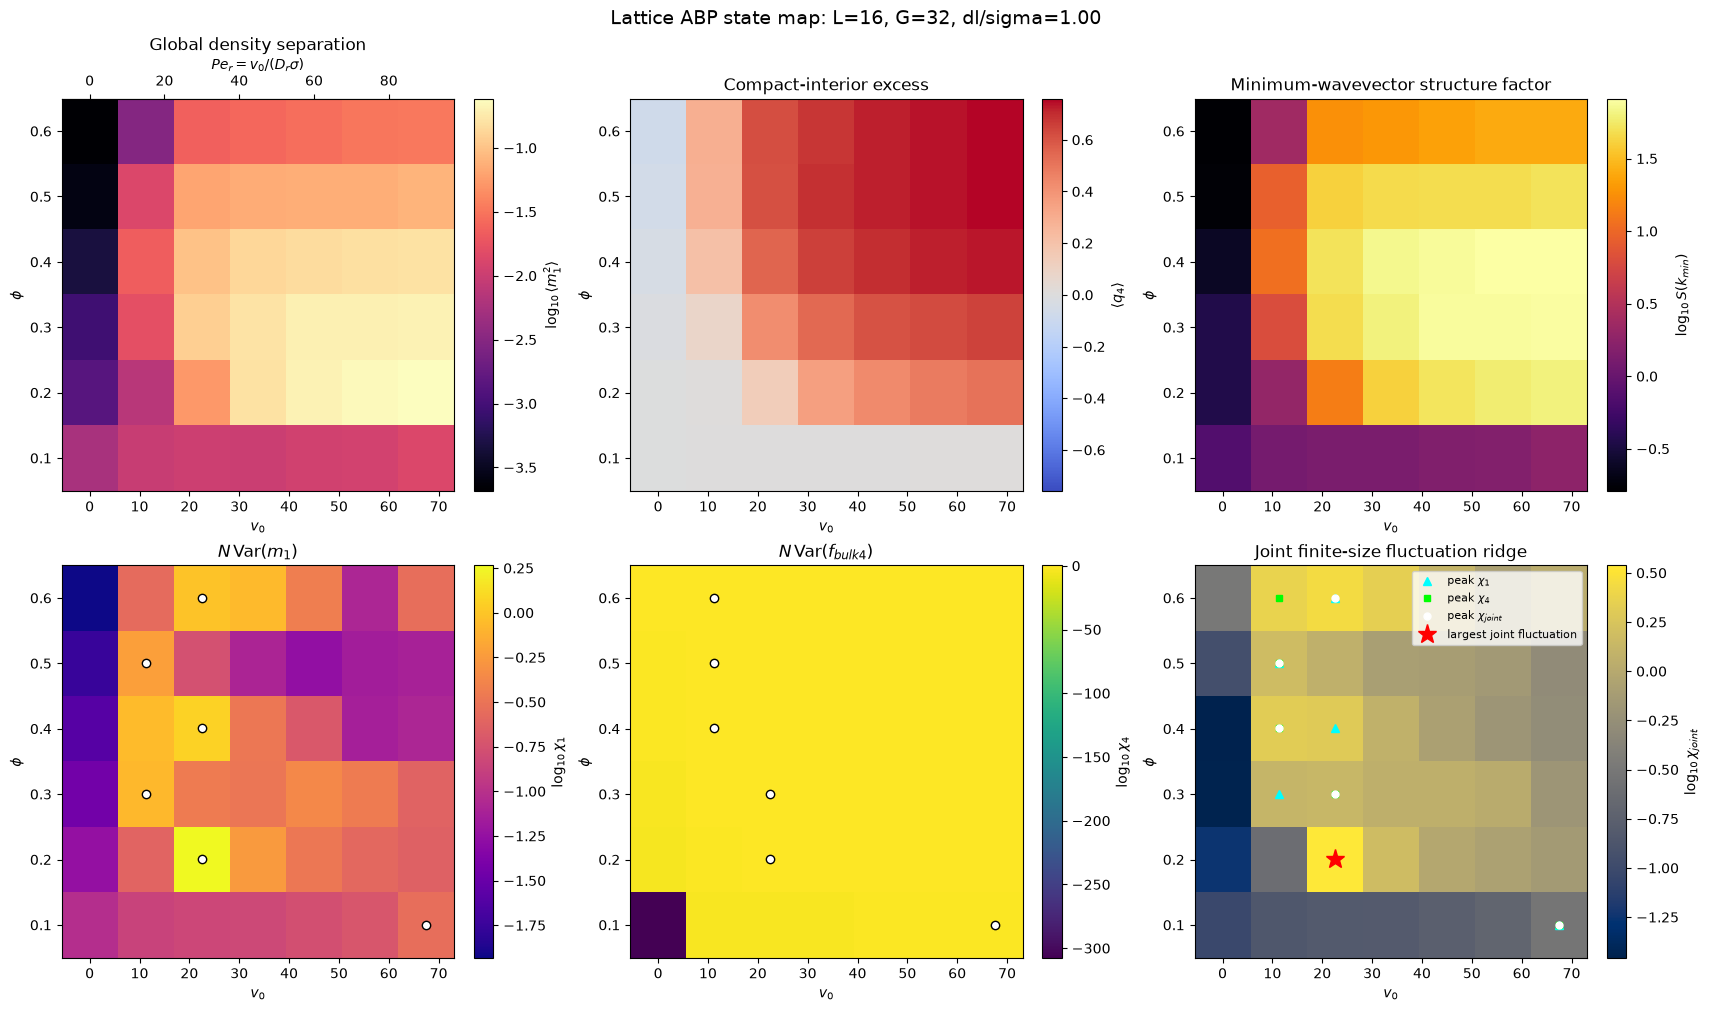

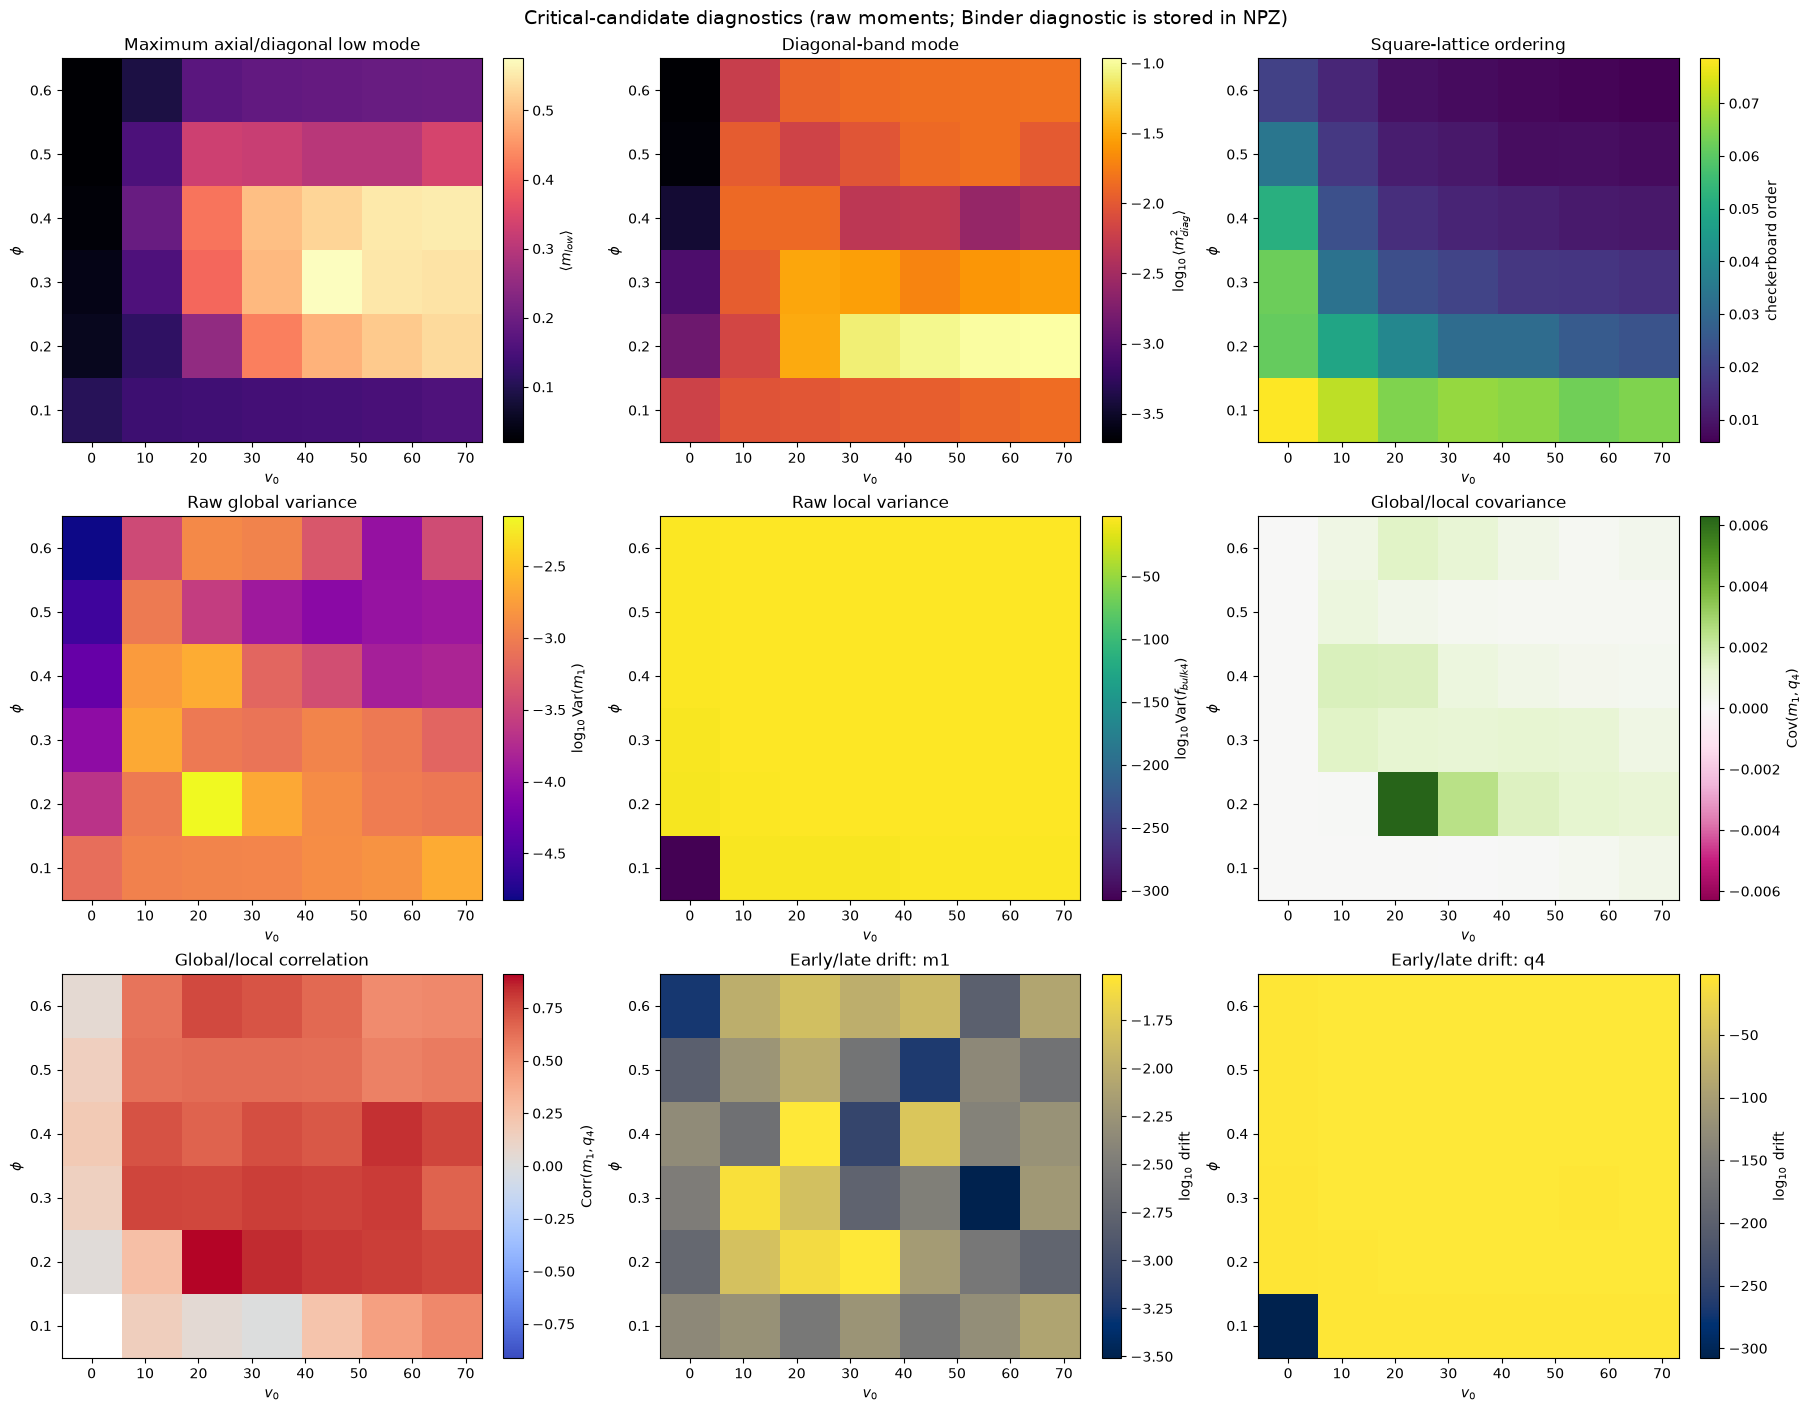

saved: /home/ldh041203/projects/CNEEP_v2/output/lattice_phase_pilot_coarse_v1_seed000/phase_diagram.png
saved: /home/ldh041203/projects/CNEEP_v2/output/lattice_phase_pilot_coarse_v1_seed000/critical_diagnostics.png

Per-phi finite-size susceptibility peaks
agreement criterion: peak Pe spread <= 15
phi       Pe(chi1)  Pe(chi4)  Pe(joint)  spread  agree  edge
0.0997      90.00     90.00      90.00    0.00   True  True
0.2002      30.00     30.00      30.00    0.00   True  False
0.2999      15.00     30.00      30.00   15.00   True  False
0.4004      30.00     15.00      15.00   15.00   True  False
0.5001      15.00     15.00      15.00    0.00   True  False
0.5998      30.00     15.00      30.00   15.00   True  False


In [8]:
if not (
    np.isfinite(m1_power).all()
    and np.isfinite(m_low_mean).all()
    and np.isfinite(bulk4_excess_mean).all()
    and np.isfinite(susceptibility_m1).all()
    and np.isfinite(susceptibility_bulk4).all()
    and np.isfinite(susceptibility_joint).all()
):
    raise RuntimeError("The scan is incomplete; run the previous cell again to resume it.")

from matplotlib.colors import TwoSlopeNorm


def log10_positive(values):
    return np.log10(np.maximum(values, np.finfo(float).tiny))


def draw_state_map(ax, values, cmap, colorbar_label, title, center_zero=False):
    mesh_kwargs = {"shading": "nearest", "cmap": cmap}
    if center_zero:
        limit = float(np.nanmax(np.abs(values)))
        limit = limit if np.isfinite(limit) and limit > 0 else 1.0
        mesh_kwargs["norm"] = TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)
    mesh = ax.pcolormesh(V_VALUES, phi_actual, values, **mesh_kwargs)
    ax.figure.colorbar(mesh, ax=ax, label=colorbar_label)
    ax.set_xlabel(r"$v_0$")
    ax.set_ylabel(r"$\phi$")
    ax.set_title(title)
    return mesh


fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)

panels = [
    (log10_positive(m1_power), "magma", r"$\log_{10}\langle m_1^2\rangle$", "Global density separation", False),
    (bulk4_excess_mean, "coolwarm", r"$\langle q_4\rangle$", "Compact-interior excess", True),
    (log10_positive(structure_factor_kmin), "inferno", r"$\log_{10} S(k_{min})$", "Minimum-wavevector structure factor", False),
    (log10_positive(susceptibility_m1), "plasma", r"$\log_{10}\chi_1$", r"$N\,\mathrm{Var}(m_1)$", False),
    (log10_positive(susceptibility_bulk4), "viridis", r"$\log_{10}\chi_4$", r"$N\,\mathrm{Var}(f_{bulk4})$", False),
    (log10_positive(susceptibility_joint), "cividis", r"$\log_{10}\chi_{joint}$", "Joint finite-size fluctuation ridge", False),
]

for ax, (values, cmap, colorbar_label, title, center_zero) in zip(axes.flat, panels):
    draw_state_map(ax, values, cmap, colorbar_label, title, center_zero)

axes[1, 0].plot(critical_ridge_v0_m1, phi_actual, "wo", ms=6, mec="black", label=r"peak $\chi_1$")
axes[1, 1].plot(critical_ridge_v0_bulk4, phi_actual, "wo", ms=6, mec="black", label=r"peak $\chi_4$")
axes[1, 2].plot(critical_ridge_v0_m1, phi_actual, "^", color="cyan", ms=6, label=r"peak $\chi_1$")
axes[1, 2].plot(critical_ridge_v0_bulk4, phi_actual, "s", color="lime", ms=5, label=r"peak $\chi_4$")
axes[1, 2].plot(critical_ridge_v0_joint, phi_actual, "wo", ms=5, label=r"peak $\chi_{joint}$")
axes[1, 2].plot(
    V_VALUES[candidate_iv], phi_actual[candidate_ip], "r*", ms=14,
    label="largest joint fluctuation",
)
axes[1, 2].legend(loc="best", fontsize=8)

top_axis = axes[0, 0].secondary_xaxis(
    "top",
    functions=(
        lambda velocity: velocity / (DR * SIGMA),
        lambda peclet: peclet * DR * SIGMA,
    ),
)
top_axis.set_xlabel(r"$Pe_r=v_0/(D_r\sigma)$")

fig.suptitle(
    f"Lattice ABP state map: L={L:g}, G={GRID_SIZE}, dl/sigma={L/GRID_SIZE/SIGMA:.2f}",
    fontsize=14,
)

figure_path = OUTDIR / "phase_diagram.png"
fig.savefig(figure_path, dpi=180)
plt.show()

diagnostic_fig, diagnostic_axes = plt.subplots(
    3, 3, figsize=(18, 14), constrained_layout=True
)
diagnostic_panels = [
    (m_low_mean, "magma", r"$\langle m_{low}\rangle$", "Maximum axial/diagonal low mode", False),
    (log10_positive(diagonal_power), "inferno", r"$\log_{10}\langle m_{diag}^2\rangle$", "Diagonal-band mode", False),
    (checkerboard, "viridis", "checkerboard order", "Square-lattice ordering", False),
    (log10_positive(m1_variance), "plasma", r"$\log_{10}\mathrm{Var}(m_1)$", "Raw global variance", False),
    (log10_positive(bulk4_fraction_variance), "viridis", r"$\log_{10}\mathrm{Var}(f_{bulk4})$", "Raw local variance", False),
    (cross_covariance_m1_bulk4_excess, "PiYG", r"$\mathrm{Cov}(m_1,q_4)$", "Global/local covariance", True),
    (m1_bulk4_correlation, "coolwarm", r"$\mathrm{Corr}(m_1,q_4)$", "Global/local correlation", True),
    (log10_positive(m1_stationarity_drift), "cividis", r"$\log_{10}$ drift", "Early/late drift: m1", False),
    (log10_positive(bulk4_stationarity_drift), "cividis", r"$\log_{10}$ drift", "Early/late drift: q4", False),
]
for ax, (values, cmap, colorbar_label, title, center_zero) in zip(
    diagnostic_axes.flat, diagnostic_panels
):
    draw_state_map(ax, values, cmap, colorbar_label, title, center_zero)

diagnostic_fig.suptitle(
    "Critical-candidate diagnostics (raw moments; Binder diagnostic is stored in NPZ)",
    fontsize=14,
)
diagnostic_path = OUTDIR / "critical_diagnostics.png"
diagnostic_fig.savefig(diagnostic_path, dpi=180)
plt.show()

print("saved:", figure_path)
print("saved:", diagnostic_path)
print("\nPer-phi finite-size susceptibility peaks")
print(f"agreement criterion: peak Pe spread <= {RIDGE_AGREEMENT_PE:g}")
print("phi       Pe(chi1)  Pe(chi4)  Pe(joint)  spread  agree  edge")
for ip, phi in enumerate(phi_actual):
    print(
        f"{phi:0.4f}   {critical_ridge_Pe_m1[ip]:8.2f}  "
        f"{critical_ridge_Pe_bulk4[ip]:8.2f}  "
        f"{critical_ridge_Pe_joint[ip]:9.2f}  "
        f"{critical_ridge_Pe_spread[ip]:6.2f}  "
        f"{str(bool(critical_ridge_agreement[ip])):>5s}  "
        f"{str(bool(critical_ridge_on_scan_edge[ip])):>4s}"
    )

## 5. Inspect representative final configurations

Occupancy is drawn as complete lattice cells. The nearest simulated state point is used for each requested `(phi, v0)` pair.

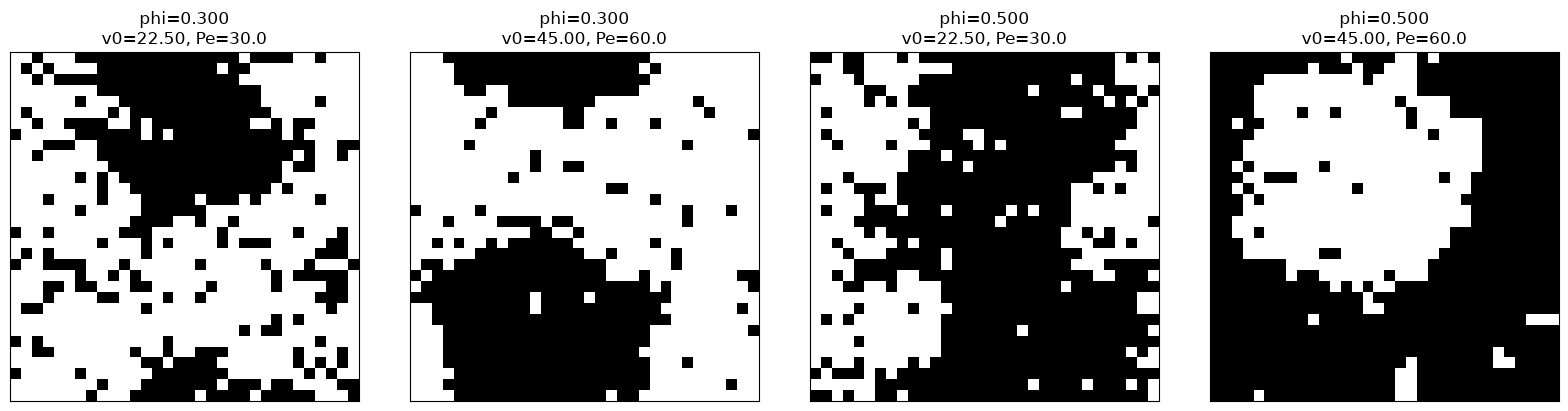

saved: /home/ldh041203/projects/CNEEP_v2/output/lattice_phase_pilot_coarse_v1_seed000/representative_states.png


In [9]:
SHOW_TARGETS = [
    (0.30, 20.0),
    (0.30, 50.0),
    (0.50, 20.0),
    (0.50, 50.0),
]

fig, axes = plt.subplots(1, len(SHOW_TARGETS), figsize=(4 * len(SHOW_TARGETS), 4), constrained_layout=True)
axes = np.atleast_1d(axes)

for ax, (target_phi, target_v) in zip(axes, SHOW_TARGETS):
    ip = int(np.argmin(np.abs(phi_actual - target_phi)))
    iv = int(np.argmin(np.abs(V_VALUES - target_v)))
    point_file = OUTDIR / f"point_phi{ip:03d}_v{iv:03d}.npz"

    with np.load(point_file) as point:
        occupancy = point["final_occupancy"]
        actual_phi = float(point["actual_phi"].item())
        actual_v = float(point["v0"].item())
        actual_pe = float(point["Pe_r"].item())

    nx, ny = occupancy.shape
    ax.pcolormesh(
        np.arange(nx + 1),
        np.arange(ny + 1),
        (occupancy.T > 0).astype(np.uint8),
        shading="flat",
        antialiased=False,
        cmap="gray_r",
        vmin=0,
        vmax=1,
    )
    ax.set_title(f"phi={actual_phi:.3f}\nv0={actual_v:.2f}, Pe={actual_pe:.1f}")
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

snapshot_path = OUTDIR / "representative_states.png"
fig.savefig(snapshot_path, dpi=180)
plt.show()
print("saved:", snapshot_path)

## 6. From pilot map to a defensible phase diagram

1. **Refine the crossover:** choose `dphi=0.025` (or smaller) and `dPe=5` around the low-mode/susceptibility change. Set `RUN_MODE="production"`, `RIDGE_AGREEMENT_PE=5.0`, and a new `OUTPUT_TAG`. Extend the range whenever a peak lands on a scan edge.
2. **Require both observables:** treat a region as a stronger finite-size candidate only when the peaks of $\chi_1$, $\chi_4$, and $\chi_{joint}$ are close and both $\langle m_1^2\rangle$ and $\langle q_4\rangle$ change consistently. `q4` alone can also respond to local lattice packing, while `m1` alone can be large for a band.
3. **Check stationarity and uncertainty:** double burn-in and production at selected boundary points. Increment `SEED_GROUP` for each independent repeat; early/late drifts and seed-group means must agree. Saved frames are autocorrelated, so their count is not an independent-sample count; use replica/seed-group means and, for final error bars, block bootstrap or an integrated-autocorrelation estimate.
4. **Locate a critical point by finite-size scaling:** hold `dl=0.5` and `dt=1e-4` fixed and repeat refined cuts at `(L, grid_size)=(16,32),(32,64),(64,128)`. Track pseudocritical peak shifts and sharpening with $L$. The notebook uses $N\,\mathrm{Var}$; compare peak heights only along fixed-$\phi$ size sequences, where $N$ is proportional to area. The saved `binder_m1_diagnostic` is not an Ising-universal Binder cumulant because `m1` is a nonnegative Fourier modulus and the global density is fixed. A universality analysis should additionally use sub-box density fluctuations/histograms with the same physical sub-box prescription across sizes.
5. **Measure the binodal from bands:** at fixed `v0`, the dilute and dense plateau packing fractions on the two sides of a stationary band should be independent of global `phi`; changing global `phi` should mainly change the band width. Those plateau curves are `phi_g(v0)` and `phi_l(v0)`. No Gaussian density map is required.
6. **Continuum-grid scaling is a separate test:** hold physical `L=16` fixed and use `(grid_size, dt)=(32,1e-4),(64,2.5e-5),(128,6.25e-6)`. This keeps `gamma^2=dl^2/dt=2500` fixed while taking `dl,dt` toward zero. `bulk4` is tied to the four lattice hopping neighbors and is therefore not grid-resolution invariant; use `m1` and physical density observables as the primary continuum comparison.

The broad scan should keep `save_diagnostics=False`, `save_exact_medium_ep=False`, and `save_ep_maps=False`; measure EPR only at selected equilibrated state points afterward. These storage choices do not approximate the dynamics.

## Outputs

The notebook writes under `output/lattice_phase_<mode>_<tag>_seedNNN/`:

- `scan_config.json`: immutable checkpoint configuration
- `analysis_config.json`: changeable joint-scale and peak-agreement settings
- `point_phiXXX_vXXX.npz`: one resumable state-point checkpoint
- `phase_summary.npz`: means, raw variances/covariance, three susceptibilities, ridge candidates, stationarity checks, and replica-level SEM estimates
- `phase_diagram.png`: `m1`, `bulk4`, structure-factor, and susceptibility maps
- `critical_diagnostics.png`: raw variance/covariance, lattice-order, and stationarity maps
- `representative_states.png`: full-cell occupancy snapshots